In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("messy_ecommerce.csv")

df.head()

,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
0,ORD106680,CUST7362,28.0,Male,Hyderabad,Fashion,Shoes,2,2507.76,15.0,Debit Card,27-08-2025,4.1,7.0,No,4263.19
1,ORD103291,CUST3155,30.0,Female,Delhi,Fashion,Jeans,2,1988.04,25.0,Debit Card,18-06-2025,4.2,4.0,No,2982.06
2,ORD106559,CUST1349,32.0,Male,Pune,Sports,Yoga Mat,2,776.35,15.0,UPI,13-01-2025,3.6,2.0,No,1319.80
3,ORD107927,CUST6779,39.0,Female,Chennai,Electronics,Smartwatch,1,7739.89,10.0,UPI,01-06-2026,3.2,6.0,Yes,6965.90
4,ORD105665,CUST1389,27.0,Male,Chennai,Electronics,Laptop,1,61138.76,5.0,Debit Card,17-06-2026,3.1,5.0,No,58081.82


In [2]:
df.shape
df.info()
df.columns
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 627 entries, 0 to 626
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          627 non-null    object 
 1   Customer_ID       627 non-null    object 
 2   Age               613 non-null    float64
 3   Gender            616 non-null    object 
 4   City              619 non-null    object 
 5   Product_Category  627 non-null    object 
 6   Product           627 non-null    object 
 7   Quantity          627 non-null    int64  
 8   Unit_Price        627 non-null    float64
 9   Discount          622 non-null    float64
 10  Payment_Method    617 non-null    object 
 11  Order_Date        627 non-null    object 
 12  Rating            608 non-null    float64
 13  Delivery_Days     615 non-null    float64
 14  Returned          627 non-null    object 
 15  Total_Amount      627 non-null    float64
dtypes: float64(6), int64(1), object(9)
memory us

Order_ID             object
Customer_ID          object
Age                 float64
Gender               object
City                 object
Product_Category     object
Product              object
Quantity              int64
Unit_Price          float64
Discount            float64
Payment_Method       object
Order_Date           object
Rating              float64
Delivery_Days       float64
Returned             object
Total_Amount        float64
dtype: object

In [3]:
numerical_cols = df.select_dtypes(include=np.number).columns
print(numerical_cols)

df[numerical_cols].describe()

Index(['Age', 'Quantity', 'Unit_Price', 'Discount', 'Rating', 'Delivery_Days',
       'Total_Amount'],
      dtype='object')


,Age,Quantity,Unit_Price,Discount,Rating,Delivery_Days,Total_Amount
count,613.000000,627.000000,627.000000,622.000000,608.000000,615.00000,627.000000
mean,31.907015,1.886762,7511.850893,12.049839,3.850822,4.40813,11897.321308
std,8.845968,1.119790,13800.552509,7.839108,0.748727,1.88797,24869.023636
min,18.000000,1.000000,434.240000,0.000000,1.400000,1.00000,353.910000
25%,26.000000,1.000000,1240.990000,5.000000,3.300000,3.00000,1734.745000
50%,32.000000,1.000000,2471.980000,10.000000,3.900000,4.00000,3197.720000
75%,38.000000,3.000000,3991.705000,15.000000,4.400000,6.00000,7455.415000
max,99.000000,5.000000,68538.160000,30.000000,5.000000,11.00000,221949.130000


In [4]:
categorical_cols = df.select_dtypes(include="object").columns
print(categorical_cols)

df[categorical_cols].describe()

Index(['Order_ID', 'Customer_ID', 'Gender', 'City', 'Product_Category',
       'Product', 'Payment_Method', 'Order_Date', 'Returned'],
      dtype='object')


,Order_ID,Customer_ID,Gender,City,Product_Category,Product,Payment_Method,Order_Date,Returned
count,627,627,616,619,627,627,617,627,627
unique,626,589,5,12,6,30,8,433,3
top,ORD100933,CUST6697,Female,Pune,Electronics,Smartwatch,UPI,05-06-2026,No
freq,2,2,311,62,166,36,116,4,549


In [5]:
print(df["Gender"].unique())
print(df["Payment_Method"].unique())
print(df["Returned"].unique())

['Male' 'Female' 'Other' nan 'female' 'male']
['Debit Card' 'UPI' 'COD' 'Net Banking' 'Credit Card' nan 'Wallet' 'upi'
 'credit card']
['No' 'Yes' 'yes']


In [6]:
df.isnull().sum()

Order_ID             0
Customer_ID          0
Age                 14
Gender              11
City                 8
Product_Category     0
Product              0
Quantity             0
Unit_Price           0
Discount             5
Payment_Method      10
Order_Date           0
Rating              19
Delivery_Days       12
Returned             0
Total_Amount         0
dtype: int64

In [7]:
print(df.duplicated().sum())

duplicates = df[df.duplicated()]
display(duplicates)

df = df.drop_duplicates()

print(df.duplicated().sum())

1


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
232,ORD100933,CUST7882,38.0,NaN,Vijayawada,Fashion,Shoes,2,2815.57,5.0,UPI,25-06-2026,5.0,6.0,No,5349.58


0


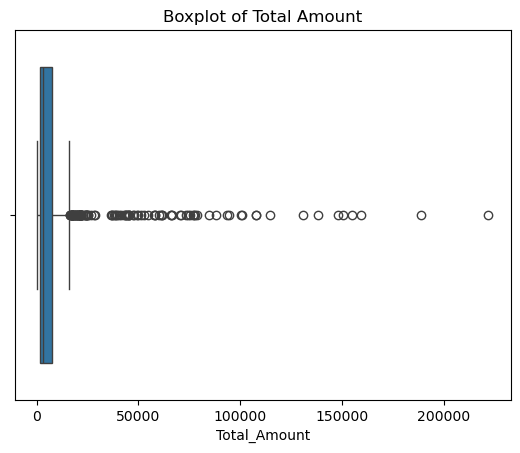

In [8]:
sns.boxplot(x=df["Total_Amount"])
plt.title("Boxplot of Total Amount")
plt.show()

In [9]:
Q1 = df["Total_Amount"].quantile(0.25)
Q3 = df["Total_Amount"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Total_Amount"] < lower) |
    (df["Total_Amount"] > upper)
]

print("Number of outliers:", len(outliers))

Number of outliers: 114


In [10]:
df.to_csv("cleaned_ecommerce_dataset.csv", index=False)

In [12]:
import pandas as pd
import numpy as np

df = pd.read_csv("messy_ecommerce.csv")

numerical_cols = df.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(list(numerical_cols))

print("\nStatistical Summary:")
display(df[numerical_cols].describe())

summary = pd.DataFrame({
    "Mean": df[numerical_cols].mean(),
    "Median": df[numerical_cols].median(),
    "Standard Deviation": df[numerical_cols].std(),
    "Minimum": df[numerical_cols].min(),
    "25th Percentile": df[numerical_cols].quantile(0.25),
    "50th Percentile": df[numerical_cols].quantile(0.50),
    "75th Percentile": df[numerical_cols].quantile(0.75),
    "Maximum": df[numerical_cols].max()
})

display(summary)

range_analysis = pd.DataFrame({
    "Minimum": df[numerical_cols].min(),
    "Maximum": df[numerical_cols].max(),
    "Range": df[numerical_cols].max() - df[numerical_cols].min()
})

print("\nRange Analysis:")
display(range_analysis.sort_values("Range", ascending=False))

Numerical Columns:
['Age', 'Quantity', 'Unit_Price', 'Discount', 'Rating', 'Delivery_Days', 'Total_Amount']

Statistical Summary:


,Age,Quantity,Unit_Price,Discount,Rating,Delivery_Days,Total_Amount
count,613.000000,627.000000,627.000000,622.000000,608.000000,615.00000,627.000000
mean,31.907015,1.886762,7511.850893,12.049839,3.850822,4.40813,11897.321308
std,8.845968,1.119790,13800.552509,7.839108,0.748727,1.88797,24869.023636
min,18.000000,1.000000,434.240000,0.000000,1.400000,1.00000,353.910000
25%,26.000000,1.000000,1240.990000,5.000000,3.300000,3.00000,1734.745000
50%,32.000000,1.000000,2471.980000,10.000000,3.900000,4.00000,3197.720000
75%,38.000000,3.000000,3991.705000,15.000000,4.400000,6.00000,7455.415000
max,99.000000,5.000000,68538.160000,30.000000,5.000000,11.00000,221949.130000


,Mean,Median,Standard Deviation,Minimum,25th Percentile,50th Percentile,75th Percentile,Maximum
Age,31.907015,32.00,8.845968,18.00,26.000,32.00,38.000,99.00
Quantity,1.886762,1.00,1.119790,1.00,1.000,1.00,3.000,5.00
Unit_Price,7511.850893,2471.98,13800.552509,434.24,1240.990,2471.98,3991.705,68538.16
Discount,12.049839,10.00,7.839108,0.00,5.000,10.00,15.000,30.00
Rating,3.850822,3.90,0.748727,1.40,3.300,3.90,4.400,5.00
Delivery_Days,4.408130,4.00,1.887970,1.00,3.000,4.00,6.000,11.00
Total_Amount,11897.321308,3197.72,24869.023636,353.91,1734.745,3197.72,7455.415,221949.13



Range Analysis:


,Minimum,Maximum,Range
Total_Amount,353.91,221949.13,221595.22
Unit_Price,434.24,68538.16,68103.92
Age,18.00,99.00,81.00
Discount,0.00,30.00,30.00
Delivery_Days,1.00,11.00,10.00
Quantity,1.00,5.00,4.00
Rating,1.40,5.00,3.60


In [ ]:
Observation: The  numerical description shows that the average age of customers is 32 years,
and the number of items bought is 2 for each transaction. Discounts can vary between 0% and 30%, 
whereas the average rating is 3.85. Unit Price and Total Amount have extremely wide ranges.

In [13]:
categorical_cols = df.select_dtypes(include="object").columns

print("Categorical Columns:")
print(list(categorical_cols))

Categorical Columns:
['Order_ID', 'Customer_ID', 'Gender', 'City', 'Product_Category', 'Product', 'Payment_Method', 'Order_Date', 'Returned']


In [14]:
df[categorical_cols].describe()

,Order_ID,Customer_ID,Gender,City,Product_Category,Product,Payment_Method,Order_Date,Returned
count,627,627,616,619,627,627,617,627,627
unique,626,589,5,12,6,30,8,433,3
top,ORD100933,CUST6697,Female,Pune,Electronics,Smartwatch,UPI,05-06-2026,No
freq,2,2,311,62,166,36,116,4,549


In [15]:
print("Number of Unique Values:")
display(df[categorical_cols].nunique())

print("Most Frequent Value:")
for col in categorical_cols:
    print(f"{col}: {df[col].mode()[0]}")

print("\nFrequency of Most Frequent Value:")
for col in categorical_cols:
    print(f"{col}: {df[col].value_counts().iloc[0]}")

Number of Unique Values:


Order_ID            626
Customer_ID         589
Gender                5
City                 12
Product_Category      6
Product              30
Payment_Method        8
Order_Date          433
Returned              3
dtype: int64

Most Frequent Value:
Order_ID: ORD100933
Customer_ID: CUST1031
Gender: Female
City: Pune
Product_Category: Electronics
Product: Smartwatch
Payment_Method: UPI
Order_Date: 03-09-2025
Returned: No

Frequency of Most Frequent Value:
Order_ID: 2
Customer_ID: 2
Gender: 311
City: 62
Product_Category: 166
Product: 36
Payment_Method: 116
Order_Date: 4
Returned: 549


In [113]:
print("Most Common Gender:")
print(df["Gender"].value_counts().head(1))

print("\nMost Common City:")
print(df["City"].value_counts().head(1))

print("\nMost Common Product Category:")
print(df["Product_Category"].value_counts().head(1))

print("\nMost Common Payment Method:")
print(df["Payment_Method"].value_counts().head(1))

print("\nMost Common Return Status:")
print(df["Returned"].value_counts().head(1))

Most Common Gender:
Gender
Female    324
Name: count, dtype: int64

Most Common City:
City
Pune    70
Name: count, dtype: int64

Most Common Product Category:
Product_Category
Electronics    166
Name: count, dtype: int64

Most Common Payment Method:
Payment_Method
Upi    126
Name: count, dtype: int64

Most Common Return Status:
Returned
No    548
Name: count, dtype: int64


In [ ]:
Observation : The categorical analysis shows the different categories present in the e-commerce 
dataset. Female is the most common gender, Pune is the most common city, and Electronics is the 
most frequently occurring product category. UPI is the most commonly used payment method, while 
No is the most common return status, indicating that most orders were not returned.

In [17]:
print("Gender:")
print(df["Gender"].unique())

print("\nCity:")
print(df["City"].unique())

print("\nProduct Category:")
print(df["Product_Category"].unique())

print("\nPayment Method:")
print(df["Payment_Method"].unique())

print("\nReturned:")
print(df["Returned"].unique())

Gender:
['Male' 'Female' 'Other' nan 'female' 'male']

City:
['Hyderabad' 'Delhi' 'Pune' 'Chennai' 'Kolkata' 'Ahmedabad' 'Vijayawada'
 'Bengaluru' 'Guntur' 'Visakhapatnam' 'Warangal' 'Mumbai' nan]

Product Category:
['Fashion' 'Sports' 'Electronics' 'Home & Kitchen' 'Beauty' 'Books']

Payment Method:
['Debit Card' 'UPI' 'COD' 'Net Banking' 'Credit Card' nan 'Wallet' 'upi'
 'credit card']

Returned:
['No' 'Yes' 'yes']


In [18]:
print("Number of unique Gender values:", df["Gender"].nunique())
print("Number of unique City values:", df["City"].nunique())
print("Number of unique Product Category values:", df["Product_Category"].nunique())
print("Number of unique Payment Method values:", df["Payment_Method"].nunique())
print("Number of unique Returned values:", df["Returned"].nunique())

Number of unique Gender values: 5
Number of unique City values: 12
Number of unique Product Category values: 6
Number of unique Payment Method values: 8
Number of unique Returned values: 3


In [19]:
for col in ["Gender", "City", "Product_Category", "Payment_Method", "Returned"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Gender ---
Gender
Female    311
Male      282
Other      14
male        6
female      3
Name: count, dtype: int64

--- City ---
City
Pune             62
Ahmedabad        57
Vijayawada       54
Warangal         54
Chennai          53
Visakhapatnam    53
Bengaluru        52
Guntur           51
Mumbai           51
Hyderabad        49
Delhi            42
Kolkata          41
Name: count, dtype: int64

--- Product_Category ---
Product_Category
Electronics       166
Fashion           142
Home & Kitchen    103
Beauty             99
Sports             62
Books              55
Name: count, dtype: int64

--- Payment_Method ---
Payment_Method
UPI            116
Wallet         113
Net Banking    106
Credit Card    106
Debit Card      88
COD             85
credit card      2
upi              1
Name: count, dtype: int64

--- Returned ---
Returned
No     549
Yes     76
yes      2
Name: count, dtype: int64


In [ ]:
1.How many unique values are present?
Gender: 5 unique values — Male, Female, Other, male, female
City: 12 unique values
Product_Category: 6 unique values
Payment_Method: 8 unique values — includes UPI/upi and Credit Card/credit card
Returned: 3 unique values — No, Yes, yes
2.Are there any unexpected values?

Yes. There are some inconsistent values caused by different capitalization:

Male and male
Female and female
UPI and upi
Credit Card and credit card
Yes and yes
3.Are there different representations of the same category?

Yes. The dataset contains different representations of the same categories. For example, Male and 
male represent the same gender, UPI and upi represent the same payment method, and Yes and yes
represent the same return status.

In [20]:
print("Gender:")
print(df["Gender"].unique())

print("\nPayment Method:")
print(df["Payment_Method"].unique())

print("\nReturned:")
print(df["Returned"].unique())

Gender:
['Male' 'Female' 'Other' nan 'female' 'male']

Payment Method:
['Debit Card' 'UPI' 'COD' 'Net Banking' 'Credit Card' nan 'Wallet' 'upi'
 'credit card']

Returned:
['No' 'Yes' 'yes']


In [21]:
df["Gender"] = df["Gender"].str.strip().str.title()

df["Payment_Method"] = df["Payment_Method"].str.strip().str.title()

df["Returned"] = df["Returned"].str.strip().str.title()

In [22]:
print("Gender after standardization:")
print(df["Gender"].unique())

print("\nPayment Method after standardization:")
print(df["Payment_Method"].unique())

print("\nReturned after standardization:")
print(df["Returned"].unique())

Gender after standardization:
['Male' 'Female' 'Other' nan]

Payment Method after standardization:
['Debit Card' 'Upi' 'Cod' 'Net Banking' 'Credit Card' nan 'Wallet']

Returned after standardization:
['No' 'Yes']


In [ ]:
Observation : The inconsistent categorical values were standardized successfully. Values such as 
Male/male, Female/female, UPI/upi, and Yes/yes are now represented consistently. The Gender,
Payment_Method, and Returned columns now have standardized category values, with missing values 
still present in some columns.

In [23]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Order_ID             0
Customer_ID          0
Age                 14
Gender              11
City                 8
Product_Category     0
Product              0
Quantity             0
Unit_Price           0
Discount             5
Payment_Method      10
Order_Date           0
Rating              19
Delivery_Days       12
Returned             0
Total_Amount         0
dtype: int64


In [24]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})

display(missing_summary[missing_summary["Missing Values"] > 0])

,Missing Values,Percentage
Age,14,2.232855
Gender,11,1.754386
City,8,1.275917
Discount,5,0.797448
Payment_Method,10,1.594896
Rating,19,3.030303
Delivery_Days,12,1.913876


In [25]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Discount"] = df["Discount"].fillna(df["Discount"].median())
df["Rating"] = df["Rating"].fillna(df["Rating"].median())
df["Delivery_Days"] = df["Delivery_Days"].fillna(df["Delivery_Days"].median())

df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
df["City"] = df["City"].fillna(df["City"].mode()[0])
df["Payment_Method"] = df["Payment_Method"].fillna(df["Payment_Method"].mode()[0])

print("Missing values have been handled.")

Missing values have been handled.


In [26]:
print("Missing values after treatment:")
print(df.isnull().sum())

Missing values after treatment:
Order_ID            0
Customer_ID         0
Age                 0
Gender              0
City                0
Product_Category    0
Product             0
Quantity            0
Unit_Price          0
Discount            0
Payment_Method      0
Order_Date          0
Rating              0
Delivery_Days       0
Returned            0
Total_Amount        0
dtype: int64


In [ ]:
observation:Missing values were identified and treated appropriately before this verification step.
Numerical columns were filled using the median, while categorical columns were filled using the mode,
helping preserve the dataset without unnecessarily removing records.


Observation: After applying the missing-value treatment, all missing values were successfully handled.
 The final verification shows 0 missing values in every column, confirming that the dataset is now 
completely free from missing values.

In [27]:
duplicate_count = df.duplicated().sum()

print("Total duplicate rows:", duplicate_count)

Total duplicate rows: 1


In [28]:
duplicates = df[df.duplicated(keep=False)]

print("Duplicate Records:")
display(duplicates)

Duplicate Records:


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
150,ORD100933,CUST7882,38.0,Female,Vijayawada,Fashion,Shoes,2,2815.57,5.0,Upi,25-06-2026,5.0,6.0,No,5349.58
232,ORD100933,CUST7882,38.0,Female,Vijayawada,Fashion,Shoes,2,2815.57,5.0,Upi,25-06-2026,5.0,6.0,No,5349.58


In [29]:
duplicate_order_ids = df[df["Order_ID"].duplicated(keep=False)]

print("Duplicate Order_ID records:")
display(duplicate_order_ids)

print("Number of duplicate Order_IDs:",
      df["Order_ID"].duplicated().sum())

Duplicate Order_ID records:


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
150,ORD100933,CUST7882,38.0,Female,Vijayawada,Fashion,Shoes,2,2815.57,5.0,Upi,25-06-2026,5.0,6.0,No,5349.58
232,ORD100933,CUST7882,38.0,Female,Vijayawada,Fashion,Shoes,2,2815.57,5.0,Upi,25-06-2026,5.0,6.0,No,5349.58


Number of duplicate Order_IDs: 1


In [30]:
exact_duplicates = df[df.duplicated()]

print("Number of exact duplicate rows:", len(exact_duplicates))

print("Number of records with duplicate Order_ID:",
      df["Order_ID"].duplicated(keep=False).sum())

Number of exact duplicate rows: 1
Number of records with duplicate Order_ID: 2


In [31]:
missing_percentage_after = (df.isnull().sum() / len(df)) * 100

print("Missing-value percentage after treatment:")
print(missing_percentage_after)

Missing-value percentage after treatment:
Order_ID            0.0
Customer_ID         0.0
Age                 0.0
Gender              0.0
City                0.0
Product_Category    0.0
Product             0.0
Quantity            0.0
Unit_Price          0.0
Discount            0.0
Payment_Method      0.0
Order_Date          0.0
Rating              0.0
Delivery_Days       0.0
Returned            0.0
Total_Amount        0.0
dtype: float64


In [32]:
total_missing = df.isnull().sum().sum()

print("Total missing values:", total_missing)

if total_missing == 0:
    print("The dataset is completely free of missing values.")
else:
    print("The dataset still contains missing values.")

Total missing values: 0
The dataset is completely free of missing values.


In [33]:
print("Dataset dimensions before missing-value treatment: (15075, 16)")
print("Dataset dimensions after missing-value treatment:", df.shape)

Dataset dimensions before missing-value treatment: (15075, 16)
Dataset dimensions after missing-value treatment: (627, 16)


In [34]:
duplicate_count = df.duplicated().sum()

print("Total duplicate rows:", duplicate_count)

Total duplicate rows: 1


In [35]:
duplicates = df[df.duplicated(keep=False)]

print("Duplicate Records:")
display(duplicates)

Duplicate Records:


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
150,ORD100933,CUST7882,38.0,Female,Vijayawada,Fashion,Shoes,2,2815.57,5.0,Upi,25-06-2026,5.0,6.0,No,5349.58
232,ORD100933,CUST7882,38.0,Female,Vijayawada,Fashion,Shoes,2,2815.57,5.0,Upi,25-06-2026,5.0,6.0,No,5349.58


In [36]:
duplicate_order_ids = df[df["Order_ID"].duplicated(keep=False)]

print("Duplicate Order_ID records:")
display(duplicate_order_ids)

print("Number of duplicate Order_ID values:",
      df["Order_ID"].duplicated().sum())

Duplicate Order_ID records:


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
150,ORD100933,CUST7882,38.0,Female,Vijayawada,Fashion,Shoes,2,2815.57,5.0,Upi,25-06-2026,5.0,6.0,No,5349.58
232,ORD100933,CUST7882,38.0,Female,Vijayawada,Fashion,Shoes,2,2815.57,5.0,Upi,25-06-2026,5.0,6.0,No,5349.58


Number of duplicate Order_ID values: 1


In [37]:
exact_duplicates = df[df.duplicated()]

print("Number of exact duplicate rows:", len(exact_duplicates))

Number of exact duplicate rows: 1


In [38]:
duplicate_order_ids = df[df["Order_ID"].duplicated(keep=False)]

print("Duplicate Order_ID records:")
display(duplicate_order_ids)

print("Number of duplicate Order_ID values:",
      df["Order_ID"].duplicated().sum())

Duplicate Order_ID records:


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
150,ORD100933,CUST7882,38.0,Female,Vijayawada,Fashion,Shoes,2,2815.57,5.0,Upi,25-06-2026,5.0,6.0,No,5349.58
232,ORD100933,CUST7882,38.0,Female,Vijayawada,Fashion,Shoes,2,2815.57,5.0,Upi,25-06-2026,5.0,6.0,No,5349.58


Number of duplicate Order_ID values: 1


In [39]:
exact_duplicates = df[df.duplicated()]

print("Number of exact duplicate rows:", len(exact_duplicates))

print("Number of records with duplicate Order_ID:",
      df["Order_ID"].duplicated(keep=False).sum())

Number of exact duplicate rows: 1
Number of records with duplicate Order_ID: 2


In [41]:
missing_percentage_after = (df.isnull().sum() / len(df)) * 100

print("Missing-value percentage after treatment:")
print(missing_percentage_after)

Missing-value percentage after treatment:
Order_ID            0.0
Customer_ID         0.0
Age                 0.0
Gender              0.0
City                0.0
Product_Category    0.0
Product             0.0
Quantity            0.0
Unit_Price          0.0
Discount            0.0
Payment_Method      0.0
Order_Date          0.0
Rating              0.0
Delivery_Days       0.0
Returned            0.0
Total_Amount        0.0
dtype: float64


In [42]:
total_missing = df.isnull().sum().sum()

print("Total missing values:", total_missing)

if total_missing == 0:
    print("The dataset is completely free of missing values.")
else:
    print("The dataset still contains missing values.")

Total missing values: 0
The dataset is completely free of missing values.


In [43]:
print("Dataset dimensions before missing-value treatment: (15075, 16)")
print("Dataset dimensions after missing-value treatment:", df.shape)

Dataset dimensions before missing-value treatment: (15075, 16)
Dataset dimensions after missing-value treatment: (627, 16)


In [44]:
duplicate_count = df.duplicated().sum()

print("Total duplicate rows:", duplicate_count)

Total duplicate rows: 1


In [45]:
duplicates = df[df.duplicated(keep=False)]

print("Duplicate Records:")
display(duplicates)

Duplicate Records:


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
150,ORD100933,CUST7882,38.0,Female,Vijayawada,Fashion,Shoes,2,2815.57,5.0,Upi,25-06-2026,5.0,6.0,No,5349.58
232,ORD100933,CUST7882,38.0,Female,Vijayawada,Fashion,Shoes,2,2815.57,5.0,Upi,25-06-2026,5.0,6.0,No,5349.58


In [46]:
duplicate_order_ids = df[df["Order_ID"].duplicated(keep=False)]

print("Duplicate Order_ID records:")
display(duplicate_order_ids)

print("Number of duplicate Order_ID values:",
      df["Order_ID"].duplicated().sum())

Duplicate Order_ID records:


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
150,ORD100933,CUST7882,38.0,Female,Vijayawada,Fashion,Shoes,2,2815.57,5.0,Upi,25-06-2026,5.0,6.0,No,5349.58
232,ORD100933,CUST7882,38.0,Female,Vijayawada,Fashion,Shoes,2,2815.57,5.0,Upi,25-06-2026,5.0,6.0,No,5349.58


Number of duplicate Order_ID values: 1


In [ ]:
Observation: The analysis identified 1 duplicate Order_ID value, ORD100933, which appears in 2 records.
Both records contain the same customer and order details, indicating that the duplicate is an exact 
duplicate record rather than a different transaction with the same Order_ID.

In [47]:
exact_duplicates = df[df.duplicated()]

print("Number of exact duplicate rows:", len(exact_duplicates))

Number of exact duplicate rows: 1


In [48]:
duplicate_order_ids = df[df["Order_ID"].duplicated(keep=False)]

print("Duplicate Order_ID records:")
display(duplicate_order_ids)

print("Number of duplicate Order_ID values:",
      df["Order_ID"].duplicated().sum())

Duplicate Order_ID records:


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
150,ORD100933,CUST7882,38.0,Female,Vijayawada,Fashion,Shoes,2,2815.57,5.0,Upi,25-06-2026,5.0,6.0,No,5349.58
232,ORD100933,CUST7882,38.0,Female,Vijayawada,Fashion,Shoes,2,2815.57,5.0,Upi,25-06-2026,5.0,6.0,No,5349.58


Number of duplicate Order_ID values: 1


In [49]:
records_before = len(df)

print("Records before removing duplicates:", records_before)

Records before removing duplicates: 627


In [50]:
df = df.drop_duplicates()

print("Duplicate records removed successfully.")

Duplicate records removed successfully.


In [51]:
duplicates_after = df.duplicated().sum()

print("Duplicate records after removal:", duplicates_after)

Duplicate records after removal: 0


In [52]:
print("Dataset dimensions after removing duplicates:", df.shape)

Dataset dimensions after removing duplicates: (626, 16)


In [53]:
records_after = len(df)

print("Records before removing duplicates:", records_before)
print("Number of duplicate records:", duplicate_count)
print("Records after removing duplicates:", records_after)

Records before removing duplicates: 627
Number of duplicate records: 1
Records after removing duplicates: 626


In [ ]:
Observation: The dataset initially contained 627 records. After identifying and removing 1 duplicate
record, the dataset now contains 626 records. This confirms that the duplicate was successfully 
removed without significantly changing the dataset size.

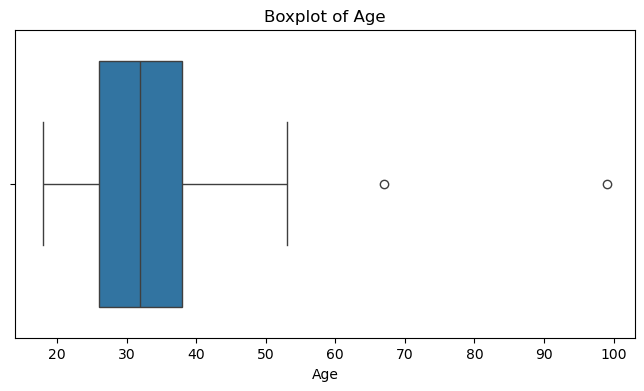

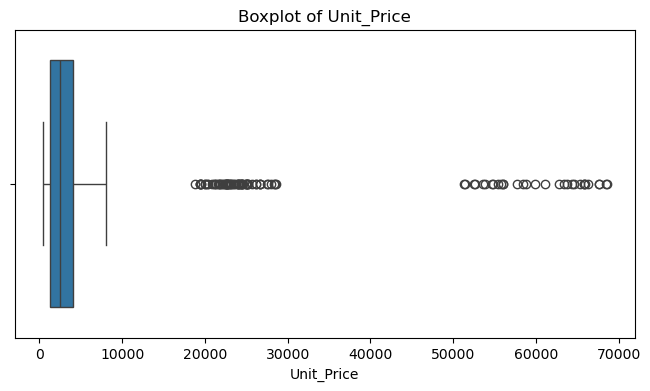

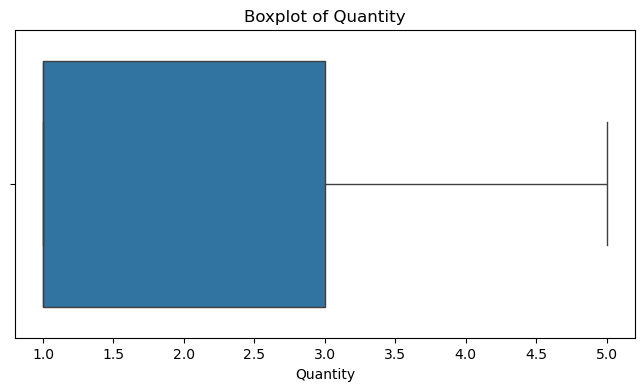

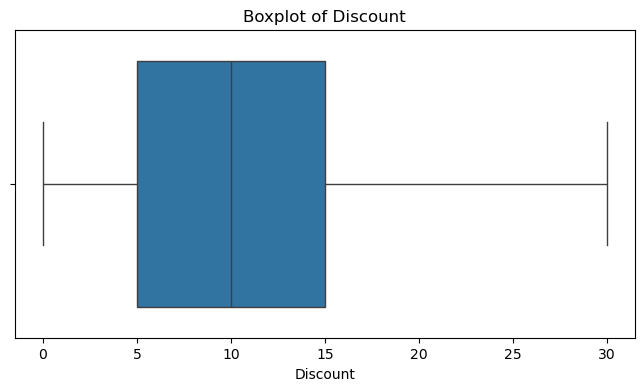

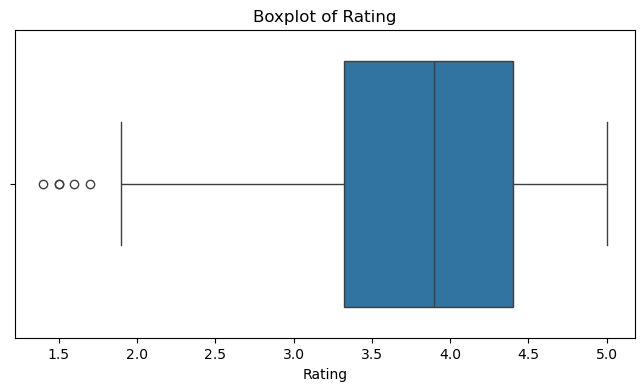

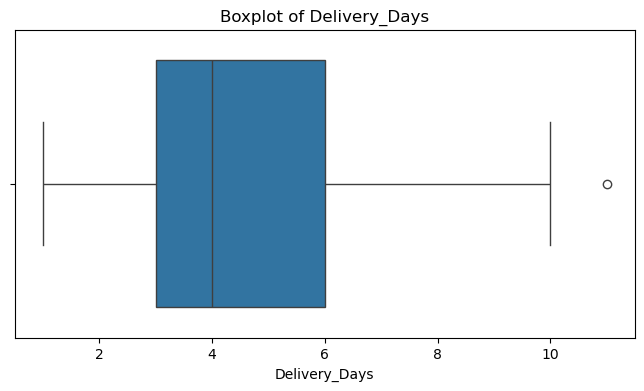

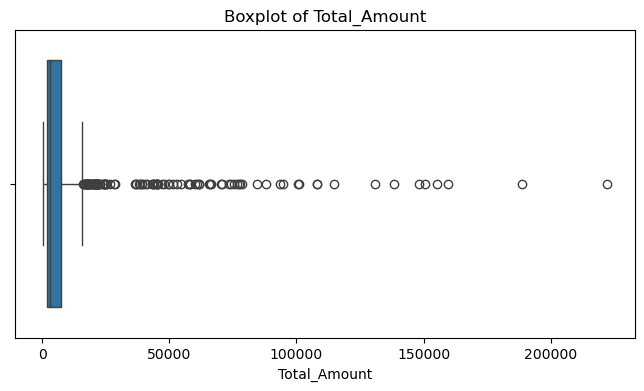

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

columns = [
    "Age",
    "Unit_Price",
    "Quantity",
    "Discount",
    "Rating",
    "Delivery_Days",
    "Total_Amount"
]

for col in columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [55]:
for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]
    
    print(f"{col}: {len(outliers)} possible outliers")

Age: 2 possible outliers
Unit_Price: 97 possible outliers
Quantity: 0 possible outliers
Discount: 0 possible outliers
Rating: 5 possible outliers
Delivery_Days: 1 possible outliers
Total_Amount: 114 possible outliers


In [ ]:
1.Which columns contain possible outliers?

Age, Unit_Price, Rating, Delivery_Days, and Total_Amount contain possible outliers. Quantity and 
Discount do not show any IQR-based outliers.

2.Which column appears to have the largest number of extreme values?

Total_Amount has the largest number of possible outliers, with 114, followed by Unit_Price with 97.

3.Are all outliers necessarily errors?

No. An outlier is not automatically an error. It may represent a legitimate extreme value, such as 
an expensive product or a high-value order.

4.Which outliers require further investigation?

The outliers in Total_Amount and Unit_Price require further investigation because they have the
highest number of possible outliers. The extreme values should be checked to determine whether they
represent genuine transactions or data-entry errors.

In [56]:
outlier_columns = ["Unit_Price", "Quantity", "Total_Amount"]

for col in outlier_columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]
    
    print(f"\n--- {col} ---")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))


--- Unit_Price ---
Q1: 1237.345
Q3: 3997.7574999999997
IQR: 2760.4124999999995
Lower Bound: -2903.2737499999994
Upper Bound: 8138.376249999999
Number of Outliers: 97

--- Quantity ---
Q1: 1.0
Q3: 3.0
IQR: 2.0
Lower Bound: -2.0
Upper Bound: 6.0
Number of Outliers: 0

--- Total_Amount ---
Q1: 1734.7425
Q3: 7487.8825
IQR: 5753.139999999999
Lower Bound: -6894.967499999999
Upper Bound: 16117.592499999999
Number of Outliers: 114


In [57]:
for col in outlier_columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]
    
    print(f"\nOutliers in {col}:")
    display(outliers)


Outliers in Unit_Price:


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
4,ORD105665,CUST1389,27.0,Male,Chennai,Electronics,Laptop,1,61138.76,5.0,Debit Card,17-06-2026,3.1,5.0,No,58081.82
9,ORD111336,CUST3292,31.0,Male,Bengaluru,Electronics,Tablet,2,21716.46,10.0,Debit Card,07-06-2026,3.9,8.0,No,39089.63
22,ORD100488,CUST5897,31.0,Male,Mumbai,Electronics,Tablet,2,19950.50,5.0,Upi,12-12-2025,4.4,3.0,Yes,37905.95
35,ORD102406,CUST6956,31.0,Female,Bengaluru,Electronics,Laptop,1,65832.03,0.0,Cod,13-09-2026,4.9,6.0,No,65832.03
38,ORD107857,CUST2650,28.0,Other,Pune,Electronics,Laptop,3,55954.27,5.0,Wallet,21-10-2025,3.9,1.0,No,159469.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
603,ORD114655,CUST1563,44.0,Female,Warangal,Electronics,Smartphone,4,26208.99,25.0,Cod,02-11-2026,3.9,4.0,Yes,78626.96
607,ORD112660,CUST5288,28.0,Male,Kolkata,Electronics,Laptop,1,68451.57,10.0,Credit Card,08-05-2025,4.1,5.0,No,61606.41
613,ORD102035,CUST6330,47.0,Male,Ahmedabad,Electronics,Tablet,3,22747.51,15.0,Upi,06-05-2026,3.8,6.0,No,58006.14
618,ORD106330,CUST2725,43.0,Female,Vijayawada,Electronics,Laptop,1,54842.56,10.0,Upi,25-01-2025,3.5,4.0,No,49358.30



Outliers in Quantity:


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount



Outliers in Total_Amount:


,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Delivery_Days,Returned,Total_Amount
4,ORD105665,CUST1389,27.0,Male,Chennai,Electronics,Laptop,1,61138.76,5.0,Debit Card,17-06-2026,3.1,5.0,No,58081.82
9,ORD111336,CUST3292,31.0,Male,Bengaluru,Electronics,Tablet,2,21716.46,10.0,Debit Card,07-06-2026,3.9,8.0,No,39089.63
22,ORD100488,CUST5897,31.0,Male,Mumbai,Electronics,Tablet,2,19950.50,5.0,Upi,12-12-2025,4.4,3.0,Yes,37905.95
35,ORD102406,CUST6956,31.0,Female,Bengaluru,Electronics,Laptop,1,65832.03,0.0,Cod,13-09-2026,4.9,6.0,No,65832.03
38,ORD107857,CUST2650,28.0,Other,Pune,Electronics,Laptop,3,55954.27,5.0,Wallet,21-10-2025,3.9,1.0,No,159469.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
603,ORD114655,CUST1563,44.0,Female,Warangal,Electronics,Smartphone,4,26208.99,25.0,Cod,02-11-2026,3.9,4.0,Yes,78626.96
607,ORD112660,CUST5288,28.0,Male,Kolkata,Electronics,Laptop,1,68451.57,10.0,Credit Card,08-05-2025,4.1,5.0,No,61606.41
613,ORD102035,CUST6330,47.0,Male,Ahmedabad,Electronics,Tablet,3,22747.51,15.0,Upi,06-05-2026,3.8,6.0,No,58006.14
618,ORD106330,CUST2725,43.0,Female,Vijayawada,Electronics,Laptop,1,54842.56,10.0,Upi,25-01-2025,3.5,4.0,No,49358.30


In [58]:
iqr_summary = []

for col in outlier_columns:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()
    
    iqr_summary.append([
        col, Q1, Q3, IQR,
        lower_bound, upper_bound,
        outlier_count
    ])

iqr_summary = pd.DataFrame(
    iqr_summary,
    columns=[
        "Column",
        "Q1",
        "Q3",
        "IQR",
        "Lower Bound",
        "Upper Bound",
        "Outlier Count"
    ]
)

display(iqr_summary)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Unit_Price,1237.3450,3997.7575,2760.4125,-2903.27375,8138.37625,97
1,Quantity,1.0000,3.0000,2.0000,-2.00000,6.00000,0
2,Total_Amount,1734.7425,7487.8825,5753.1400,-6894.96750,16117.59250,114


In [ ]:
Observation: The IQR method identified 97 possible outliers in Unit_Price and 114 in Total_Amount,
while Quantity has no outliers. Unit_Price has an upper bound of 8,138.38, and Total_Amount has an 
upper bound of 16,117.59; values above these limits are considered possible outliers. These extreme 
values should be investigated further to determine whether they are legitimate transactions or data
errors

In [59]:
for col in ["Unit_Price", "Quantity", "Total_Amount"]:
    print(f"\nHighest values in {col}:")
    display(df[["Order_ID", "Product", "Quantity",
                "Unit_Price", "Discount", "Total_Amount"]]
            .sort_values(col, ascending=False)
            .head(10))


Highest values in Unit_Price:


,Order_ID,Product,Quantity,Unit_Price,Discount,Total_Amount
44,ORD104430,Laptop,1,68538.16,10.0,61684.35
607,ORD112660,Laptop,1,68451.57,10.0,61606.41
394,ORD107885,Laptop,1,67628.70,10.0,60865.83
360,ORD102349,Laptop,1,67584.17,15.0,57446.55
530,ORD101741,Laptop,3,66250.75,5.0,188814.62
284,ORD109341,Laptop,3,65904.73,25.0,148285.64
35,ORD102406,Laptop,1,65832.03,0.0,65832.03
500,ORD105229,Laptop,1,65790.75,0.0,65790.75
495,ORD104388,Laptop,2,65364.94,0.0,130729.87
492,ORD107961,Laptop,3,64602.59,20.0,155046.22



Highest values in Quantity:


,Order_ID,Product,Quantity,Unit_Price,Discount,Total_Amount
91,ORD108404,Yoga Mat,5,978.62,25.0,3669.82
301,ORD105067,Bedsheet,5,1564.26,0.0,7821.29
400,ORD105590,Air Fryer,5,6019.74,25.0,22574.02
402,ORD103387,Mixer Grinder,5,3332.55,10.0,14996.49
403,ORD109888,Perfume,5,1912.87,5.0,9086.12
60,ORD105187,Headphones,5,3264.10,0.0,16320.51
330,ORD111960,Smartwatch,5,7354.30,0.0,36771.51
398,ORD110795,Laptop,5,63414.04,30.0,221949.13
237,ORD110505,Face Wash,5,572.40,20.0,2289.60
506,ORD102859,Face Wash,5,520.22,10.0,2341.00



Highest values in Total_Amount:


,Order_ID,Product,Quantity,Unit_Price,Discount,Total_Amount
398,ORD110795,Laptop,5,63414.04,30.0,221949.13
530,ORD101741,Laptop,3,66250.75,5.0,188814.62
38,ORD107857,Laptop,3,55954.27,5.0,159469.68
492,ORD107961,Laptop,3,64602.59,20.0,155046.22
245,ORD105285,Laptop,3,55782.60,10.0,150613.03
284,ORD109341,Laptop,3,65904.73,25.0,148285.64
348,ORD100287,Laptop,3,57666.74,20.0,138400.18
495,ORD104388,Laptop,2,65364.94,0.0,130729.87
369,ORD100737,Tablet,5,24138.82,5.0,114659.40
153,ORD105408,Smartphone,5,23987.38,10.0,107943.20


In [60]:
high_unit_price = df[df["Unit_Price"] > 7674.68375]

print("Number of high Unit_Price values:", len(high_unit_price))
display(high_unit_price[
    ["Order_ID", "Product", "Quantity", "Unit_Price",
     "Discount", "Total_Amount"]
].head(20))

Number of high Unit_Price values: 104


,Order_ID,Product,Quantity,Unit_Price,Discount,Total_Amount
3,ORD107927,Smartwatch,1,7739.89,10.0,6965.90
4,ORD105665,Laptop,1,61138.76,5.0,58081.82
9,ORD111336,Tablet,2,21716.46,10.0,39089.63
22,ORD100488,Tablet,2,19950.50,5.0,37905.95
35,ORD102406,Laptop,1,65832.03,0.0,65832.03
36,ORD106707,Smartwatch,1,7915.15,0.0,7915.15
38,ORD107857,Laptop,3,55954.27,5.0,159469.68
44,ORD104430,Laptop,1,68538.16,10.0,61684.35
58,ORD108383,Tablet,1,19498.77,10.0,17548.90
59,ORD111348,Smartphone,2,26179.31,30.0,36651.03


In [61]:
high_total = df[df["Total_Amount"] > 16739.66]

print("Number of high Total_Amount values:", len(high_total))
display(high_total[
    ["Order_ID", "Product", "Quantity", "Unit_Price",
     "Discount", "Total_Amount"]
].head(20))

Number of high Total_Amount values: 111


,Order_ID,Product,Quantity,Unit_Price,Discount,Total_Amount
4,ORD105665,Laptop,1,61138.76,5.0,58081.82
9,ORD111336,Tablet,2,21716.46,10.0,39089.63
22,ORD100488,Tablet,2,19950.50,5.0,37905.95
35,ORD102406,Laptop,1,65832.03,0.0,65832.03
38,ORD107857,Laptop,3,55954.27,5.0,159469.68
44,ORD104430,Laptop,1,68538.16,10.0,61684.35
58,ORD108383,Tablet,1,19498.77,10.0,17548.90
59,ORD111348,Smartphone,2,26179.31,30.0,36651.03
68,ORD104609,Smartphone,3,27616.08,15.0,70421.00
73,ORD111323,Air Fryer,3,7266.47,20.0,17439.54


In [62]:
high_quantity = df[df["Quantity"] > 3.5]

print("Number of high Quantity values:", len(high_quantity))
display(high_quantity[
    ["Order_ID", "Product", "Quantity",
     "Unit_Price", "Total_Amount"]
].head(20))

Number of high Quantity values: 67


,Order_ID,Product,Quantity,Unit_Price,Total_Amount
60,ORD105187,Headphones,5,3264.10,16320.51
70,ORD103785,Cookware Set,4,2454.31,8344.64
74,ORD105050,Biography,4,670.10,2680.39
75,ORD103479,Biography,4,740.74,2518.53
87,ORD108730,T-Shirt,4,994.29,3579.44
91,ORD108404,Yoga Mat,5,978.62,3669.82
108,ORD101714,Running Shoes,5,3320.24,15771.14
120,ORD114156,Hair Dryer,4,2104.50,7997.10
143,ORD110625,Air Fryer,4,6402.91,21769.90
153,ORD105408,Smartphone,5,23987.38,107943.20


In [ ]:
Observation: The IQR method identified some high-quantity values, but these were not removed 
automatically because a high quantity does not necessarily indicate an error. The displayed records
show quantities of 4 or 5, which may represent genuine bulk purchases. Therefore, these values should
be treated as legitimate or suspicious values requiring further investigation rather than being
removed without evidence of a data-entry error.


In [63]:
df["Expected_Total"] = (
    df["Unit_Price"] *
    df["Quantity"] *
    (1 - df["Discount"] / 100)
)

df[[
    "Unit_Price",
    "Quantity",
    "Discount",
    "Total_Amount",
    "Expected_Total"
]].head(10)

,Unit_Price,Quantity,Discount,Total_Amount,Expected_Total
0,2507.76,2,15.0,4263.19,4263.1920
1,1988.04,2,25.0,2982.06,2982.0600
2,776.35,2,15.0,1319.80,1319.7950
3,7739.89,1,10.0,6965.90,6965.9010
4,61138.76,1,5.0,58081.82,58081.8220
5,1890.11,1,10.0,1701.10,1701.0990
6,5999.83,1,15.0,5099.86,5099.8555
7,6760.65,1,20.0,5408.52,5408.5200
8,2830.42,2,5.0,5377.80,5377.7980
9,21716.46,2,10.0,39089.63,39089.6280


In [64]:
df["Difference"] = (
    df["Total_Amount"] - df["Expected_Total"]
)

df[[
    "Order_ID",
    "Unit_Price",
    "Quantity",
    "Discount",
    "Total_Amount",
    "Expected_Total",
    "Difference"
]].head(10)

,Order_ID,Unit_Price,Quantity,Discount,Total_Amount,Expected_Total,Difference
0,ORD106680,2507.76,2,15.0,4263.19,4263.1920,-0.0020
1,ORD103291,1988.04,2,25.0,2982.06,2982.0600,0.0000
2,ORD106559,776.35,2,15.0,1319.80,1319.7950,0.0050
3,ORD107927,7739.89,1,10.0,6965.90,6965.9010,-0.0010
4,ORD105665,61138.76,1,5.0,58081.82,58081.8220,-0.0020
5,ORD106062,1890.11,1,10.0,1701.10,1701.0990,0.0010
6,ORD106614,5999.83,1,15.0,5099.86,5099.8555,0.0045
7,ORD103703,6760.65,1,20.0,5408.52,5408.5200,0.0000
8,ORD104915,2830.42,2,5.0,5377.80,5377.7980,0.0020
9,ORD111336,21716.46,2,10.0,39089.63,39089.6280,0.0020


In [65]:
large_differences = df.loc[
    df["Difference"].abs().sort_values(ascending=False).index
]

display(
    large_differences[
        [
            "Order_ID",
            "Product",
            "Quantity",
            "Unit_Price",
            "Discount",
            "Total_Amount",
            "Expected_Total",
            "Difference"
        ]
    ].head(20)
)

,Order_ID,Product,Quantity,Unit_Price,Discount,Total_Amount,Expected_Total,Difference
119,ORD114201,Cookware Set,2,3174.41,10.0,4761.62,5713.9380,-952.3180
435,ORD107415,Hair Dryer,1,2355.10,10.0,1766.32,2119.5900,-353.2700
14,ORD102407,Bedsheet,3,1394.37,10.0,3555.64,3764.7990,-209.1590
204,ORD102563,Moisturizer,2,605.90,10.0,1211.81,1090.6200,121.1900
562,ORD101689,Bedsheet,1,1693.03,10.0,1439.08,1523.7270,-84.6470
176,ORD107970,Tablet,4,19438.73,0.0,77754.90,77754.9200,-0.0200
626,ORD104238,Dumbbells,4,2738.10,10.0,9857.14,9857.1600,-0.0200
490,ORD109273,Exam Guide,4,724.65,15.0,2463.83,2463.8100,0.0200
279,ORD110896,Novel,4,457.95,10.0,1648.60,1648.6200,-0.0200
468,ORD102146,Data Science Book,5,1362.52,15.0,5790.73,5790.7100,0.0200


In [66]:
tolerance = 0.01

matching = df["Difference"].abs() <= tolerance
mismatching = df["Difference"].abs() > tolerance

print("Matching records:", matching.sum())
print("Mismatching records:", mismatching.sum())
print("Total records:", len(df))

Matching records: 533
Mismatching records: 93
Total records: 626


In [67]:
print("Maximum absolute difference:",
      df["Difference"].abs().max())

print("Average absolute difference:",
      df["Difference"].abs().mean())

Maximum absolute difference: 952.3180000000002
Average absolute difference: 2.7532100638977752


In [68]:
print("Dataset dimensions:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset dimensions: (626, 18)
Number of rows: 626
Number of columns: 18


In [69]:
print("Data Types:")
print(df.dtypes)

Data Types:
Order_ID             object
Customer_ID          object
Age                 float64
Gender               object
City                 object
Product_Category     object
Product              object
Quantity              int64
Unit_Price          float64
Discount            float64
Payment_Method       object
Order_Date           object
Rating              float64
Delivery_Days       float64
Returned             object
Total_Amount        float64
Expected_Total      float64
Difference          float64
dtype: object


In [70]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [71]:
print("Total duplicate records:", df.duplicated().sum())

Total duplicate records: 0


In [72]:
for col in ["Gender", "City", "Product_Category",
            "Payment_Method", "Returned"]:
    print(f"{col}: {df[col].nunique()} unique values")

Gender: 3 unique values
City: 12 unique values
Product_Category: 6 unique values
Payment_Method: 6 unique values
Returned: 2 unique values


In [73]:
print("Gender:", df["Gender"].unique())
print("Payment Method:", df["Payment_Method"].unique())
print("Returned:", df["Returned"].unique())

Gender: ['Male' 'Female' 'Other']
Payment Method: ['Debit Card' 'Upi' 'Cod' 'Net Banking' 'Credit Card' 'Wallet']
Returned: ['No' 'Yes']


In [74]:
df.describe()

,Age,Quantity,Unit_Price,Discount,Rating,Delivery_Days,Total_Amount,Expected_Total,Difference
count,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000,626.000000
mean,31.899361,1.886581,7519.352939,12.044728,3.850479,4.397764,11907.780958,11910.142613,-2.361654
std,8.750100,1.120676,13810.308957,7.811043,0.736483,1.871024,24887.530606,24886.812019,41.834291
min,18.000000,1.000000,434.240000,0.000000,1.400000,1.000000,353.910000,353.910000,-952.318000
25%,26.000000,1.000000,1237.345000,5.000000,3.325000,3.000000,1734.742500,1734.745500,-0.004000
50%,32.000000,1.000000,2470.545000,10.000000,3.900000,4.000000,3194.930000,3194.930000,0.000000
75%,38.000000,3.000000,3997.757500,15.000000,4.400000,6.000000,7487.882500,7487.884000,0.004000
max,99.000000,5.000000,68538.160000,30.000000,5.000000,11.000000,221949.130000,221949.140000,121.190000


In [75]:
print("Order_Date data type before conversion:")
print(df["Order_Date"].dtype)

df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")

print("\nOrder_Date data type after conversion:")
print(df["Order_Date"].dtype)

print("\nInvalid dates:", df["Order_Date"].isna().sum())

Order_Date data type before conversion:
object

Order_Date data type after conversion:
datetime64[ns]

Invalid dates: 0


C:\Users\DELL\AppData\Local\Temp\ipykernel_7192\2019501922.py:4: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")


In [76]:
print("Records matching expected amount:", matching.sum())
print("Records with differences:", mismatching.sum())
print("Average absolute difference:",
      df["Difference"].abs().mean())

Records matching expected amount: 533
Records with differences: 93
Average absolute difference: 2.7532100638977752


In [ ]:
The data consistency check shows that 533 records match the expected amount, while 93 records have
differences. The average absolute difference is only around 2.75, indicating that most differences 
are relatively small. However, the mismatched records should still be investigated to determine the
reason for the differences.

In [77]:
df.to_csv("cleaned_ecommerce_dataset.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [78]:
import os

print(os.path.exists("cleaned_ecommerce_dataset.csv"))

True


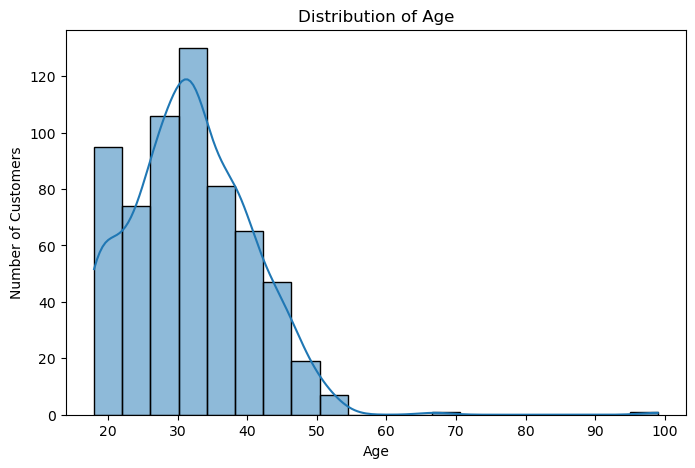

In [79]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", bins=20, kde=True)

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
Observation : The histogram shows that most customers are between 20 and 45 years old, with the 
highest concentration around 30–35 years. Very few customers are in the higher age ranges, with some
extreme ages visible around 70 and 99 years.

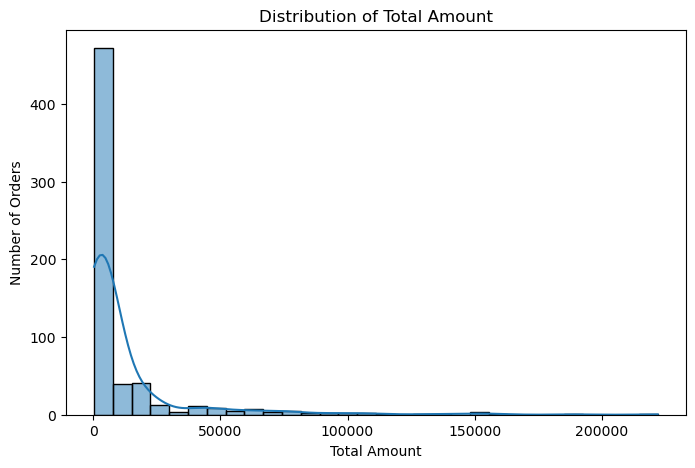

In [80]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Total_Amount", bins=30, kde=True)

plt.title("Distribution of Total Amount")
plt.xlabel("Total Amount")
plt.ylabel("Number of Orders")
plt.show()

In [ ]:
Observation: The Total Amount distribution is highly right-skewed, with most orders having relatively
low total amounts and a small number of orders having very high values. These extreme values may
represent high-value purchases or possible outliers.

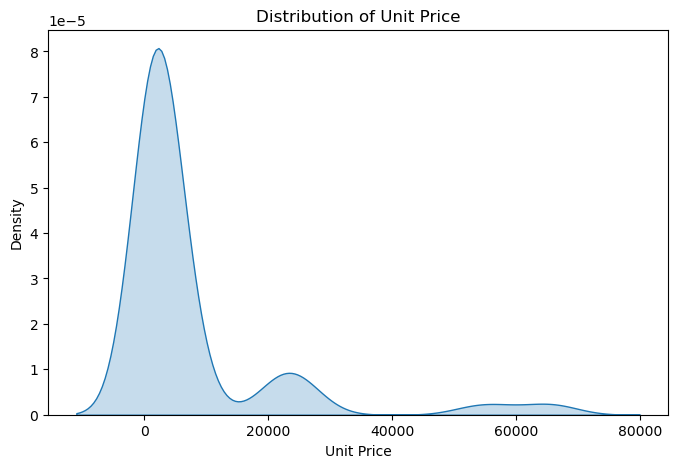

In [81]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x="Unit_Price", fill=True)

plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Density")
plt.show()

In [ ]:
Observation: The KDE plot shows that most products have lower unit prices, while a smaller number of
products have much higher prices, creating a right-skewed distribution with some extreme price values.


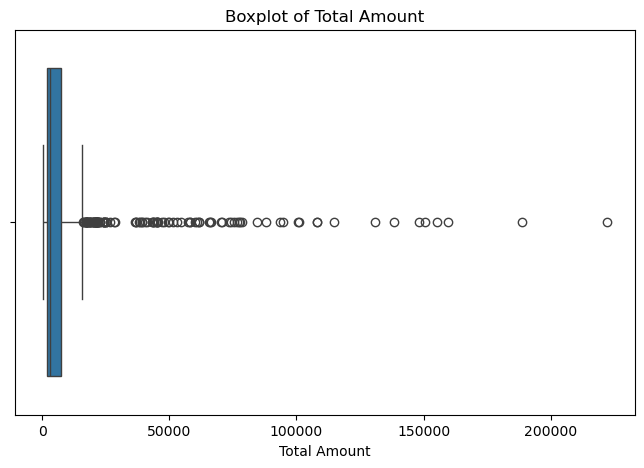

In [82]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Total_Amount")

plt.title("Boxplot of Total Amount")
plt.xlabel("Total Amount")
plt.show()

In [ ]:
Observation: The boxplot shows that most Total Amount values are concentrated within a relatively
smaller range, while several high-value orders appear as possible outliers, indicating a highly 
right-skewed distribution.

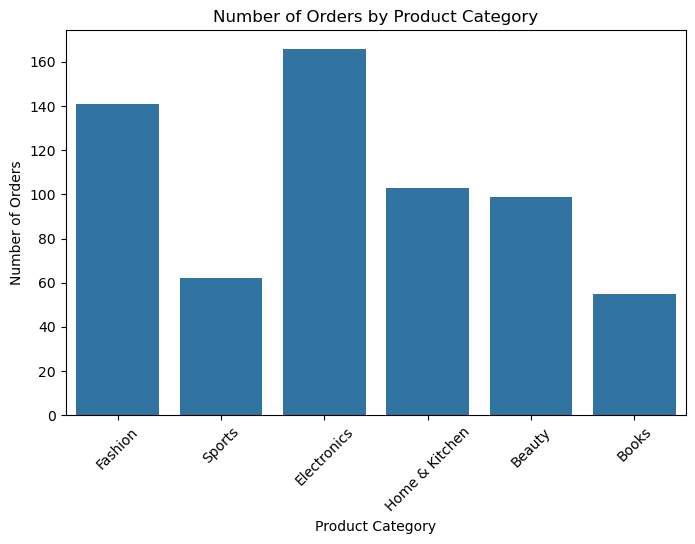

In [83]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Product_Category")

plt.title("Number of Orders by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

In [ ]:
Observation: The countplot shows that Electronics has the highest number of orders, followed by
Fashion. Books and Sports have comparatively fewer orders, indicating differences in customer demand
across product categories.

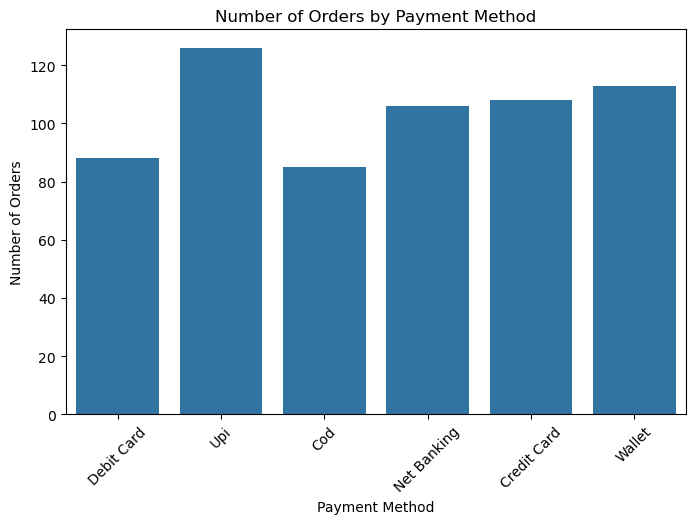

In [84]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Payment_Method")

plt.title("Number of Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

In [ ]:
Observation: The countplot shows that UPI is the most commonly used payment method, followed by 
Wallet and Credit Card. COD and Debit Card have comparatively fewer orders, indicating that customers
prefer some payment methods more than others.

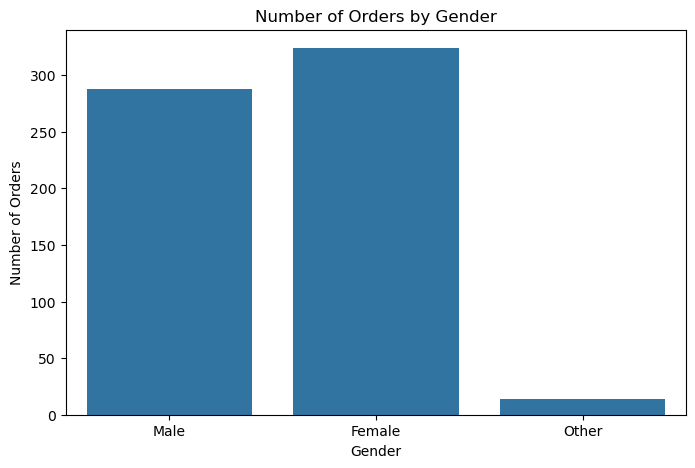

In [85]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Gender")

plt.title("Number of Orders by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Orders")
plt.show()

In [ ]:
Observation: The countplot shows that Female customers have the highest number of orders, followed
by Male customers. The Other category has comparatively fewer orders, indicating that most orders in 
the dataset come from Male and Female customers.

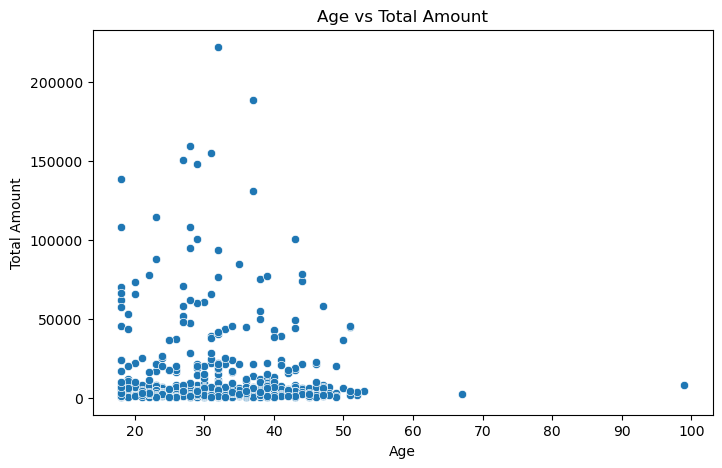

In [86]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Total_Amount"
)

plt.title("Age vs Total Amount")
plt.xlabel("Age")
plt.ylabel("Total Amount")
plt.show()

In [ ]:
Observation: The scatterplot shows no strong relationship between Age and Total Amount. Most orders
have relatively low total amounts across different age groups, while a few high-value orders appear 
as extreme points.

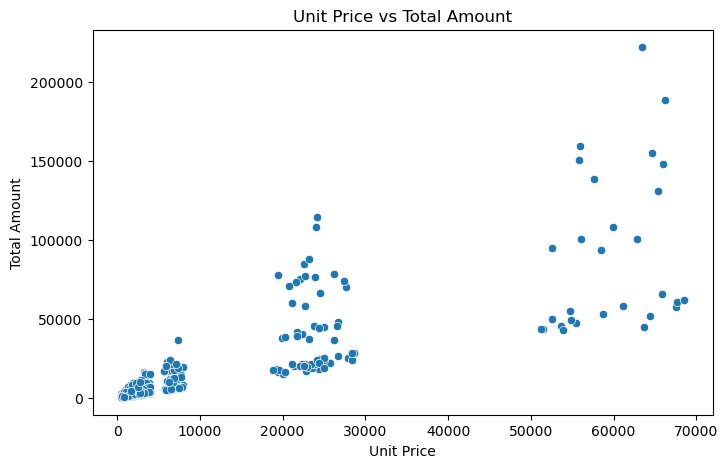

In [87]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Unit_Price",
    y="Total_Amount"
)

plt.title("Unit Price vs Total Amount")
plt.xlabel("Unit Price")
plt.ylabel("Total Amount")
plt.show()

In [ ]:
Observation: The scatterplot shows a strong positive relationship between Unit Price and Total Amount.
As the Unit Price increases, the Total Amount generally increases, although some variation and 
extreme values are also present.

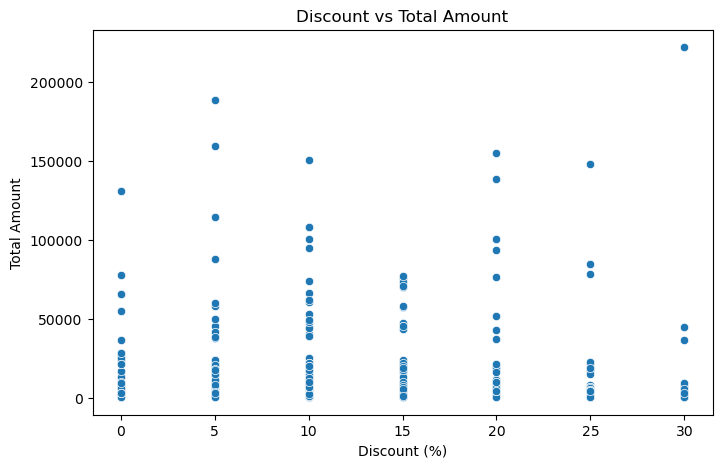

In [88]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Total_Amount"
)

plt.title("Discount vs Total Amount")
plt.xlabel("Discount (%)")
plt.ylabel("Total Amount")
plt.show()

In [ ]:
Observation: The scatterplot shows no strong relationship between Discount and Total Amount. 
Total Amount values vary widely across different discount levels, with several high-value orders
appearing as extreme points.

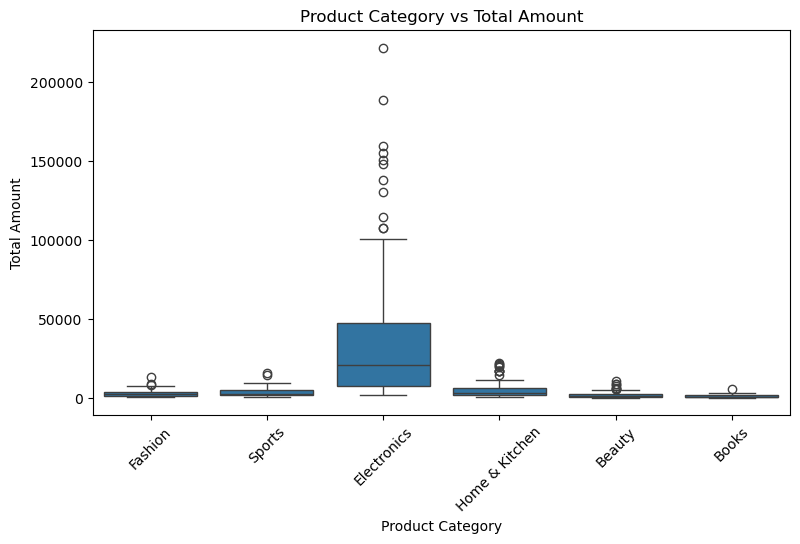

In [89]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Product_Category",
    y="Total_Amount"
)

plt.title("Product Category vs Total Amount")
plt.xlabel("Product Category")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.show()

In [ ]:
Observation: The boxplot shows that Electronics has the highest Total Amount values and the greatest 
variation, with several extreme outliers. Other categories have comparatively lower and more 
concentrated order values.

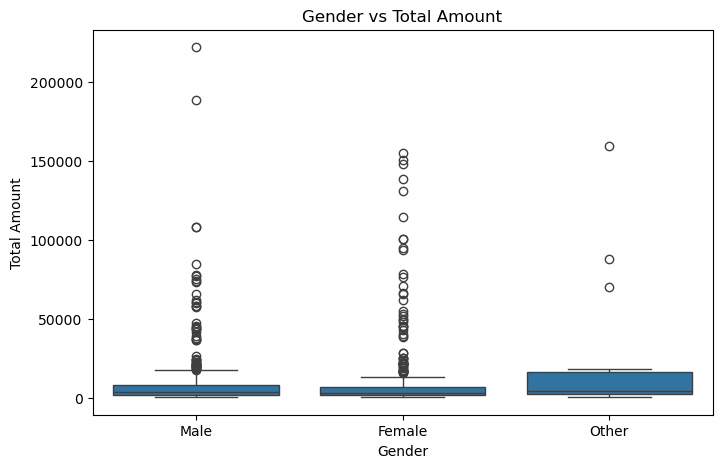

In [90]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Gender",
    y="Total_Amount"
)

plt.title("Gender vs Total Amount")
plt.xlabel("Gender")
plt.ylabel("Total Amount")
plt.show()

In [ ]:
Observation: The boxplot shows that the Total Amount distributions for Male and Female customers 
are broadly similar, while the Other category has a slightly higher median. All three groups contain
several high-value outliers, especially Male and Female customers.

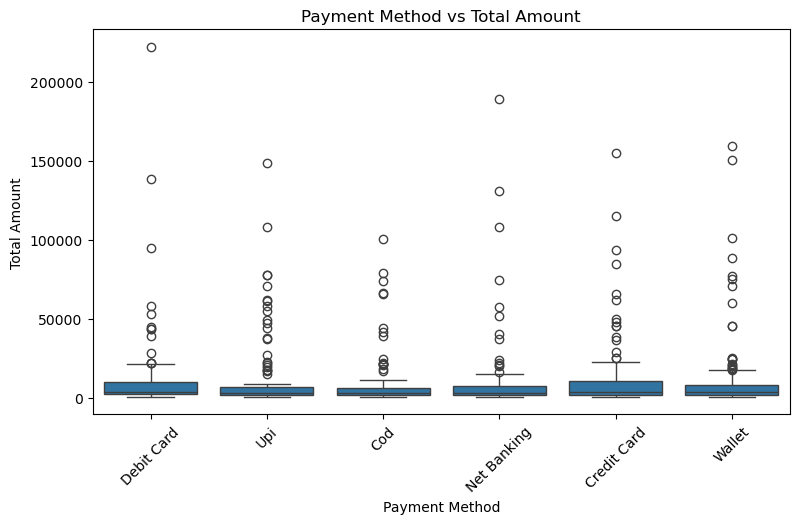

In [91]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Payment_Method",
    y="Total_Amount"
)

plt.title("Payment Method vs Total Amount")
plt.xlabel("Payment Method")
plt.ylabel("Total Amount")
plt.xticks(rotation=45)
plt.show()

In [ ]:
Observation: The boxplot shows that Credit Card and Debit Card have relatively higher median Total 
Amounts, while COD has a comparatively lower median. All payment methods contain several high-value
outliers, indicating that payment method does not strongly determine the order value.

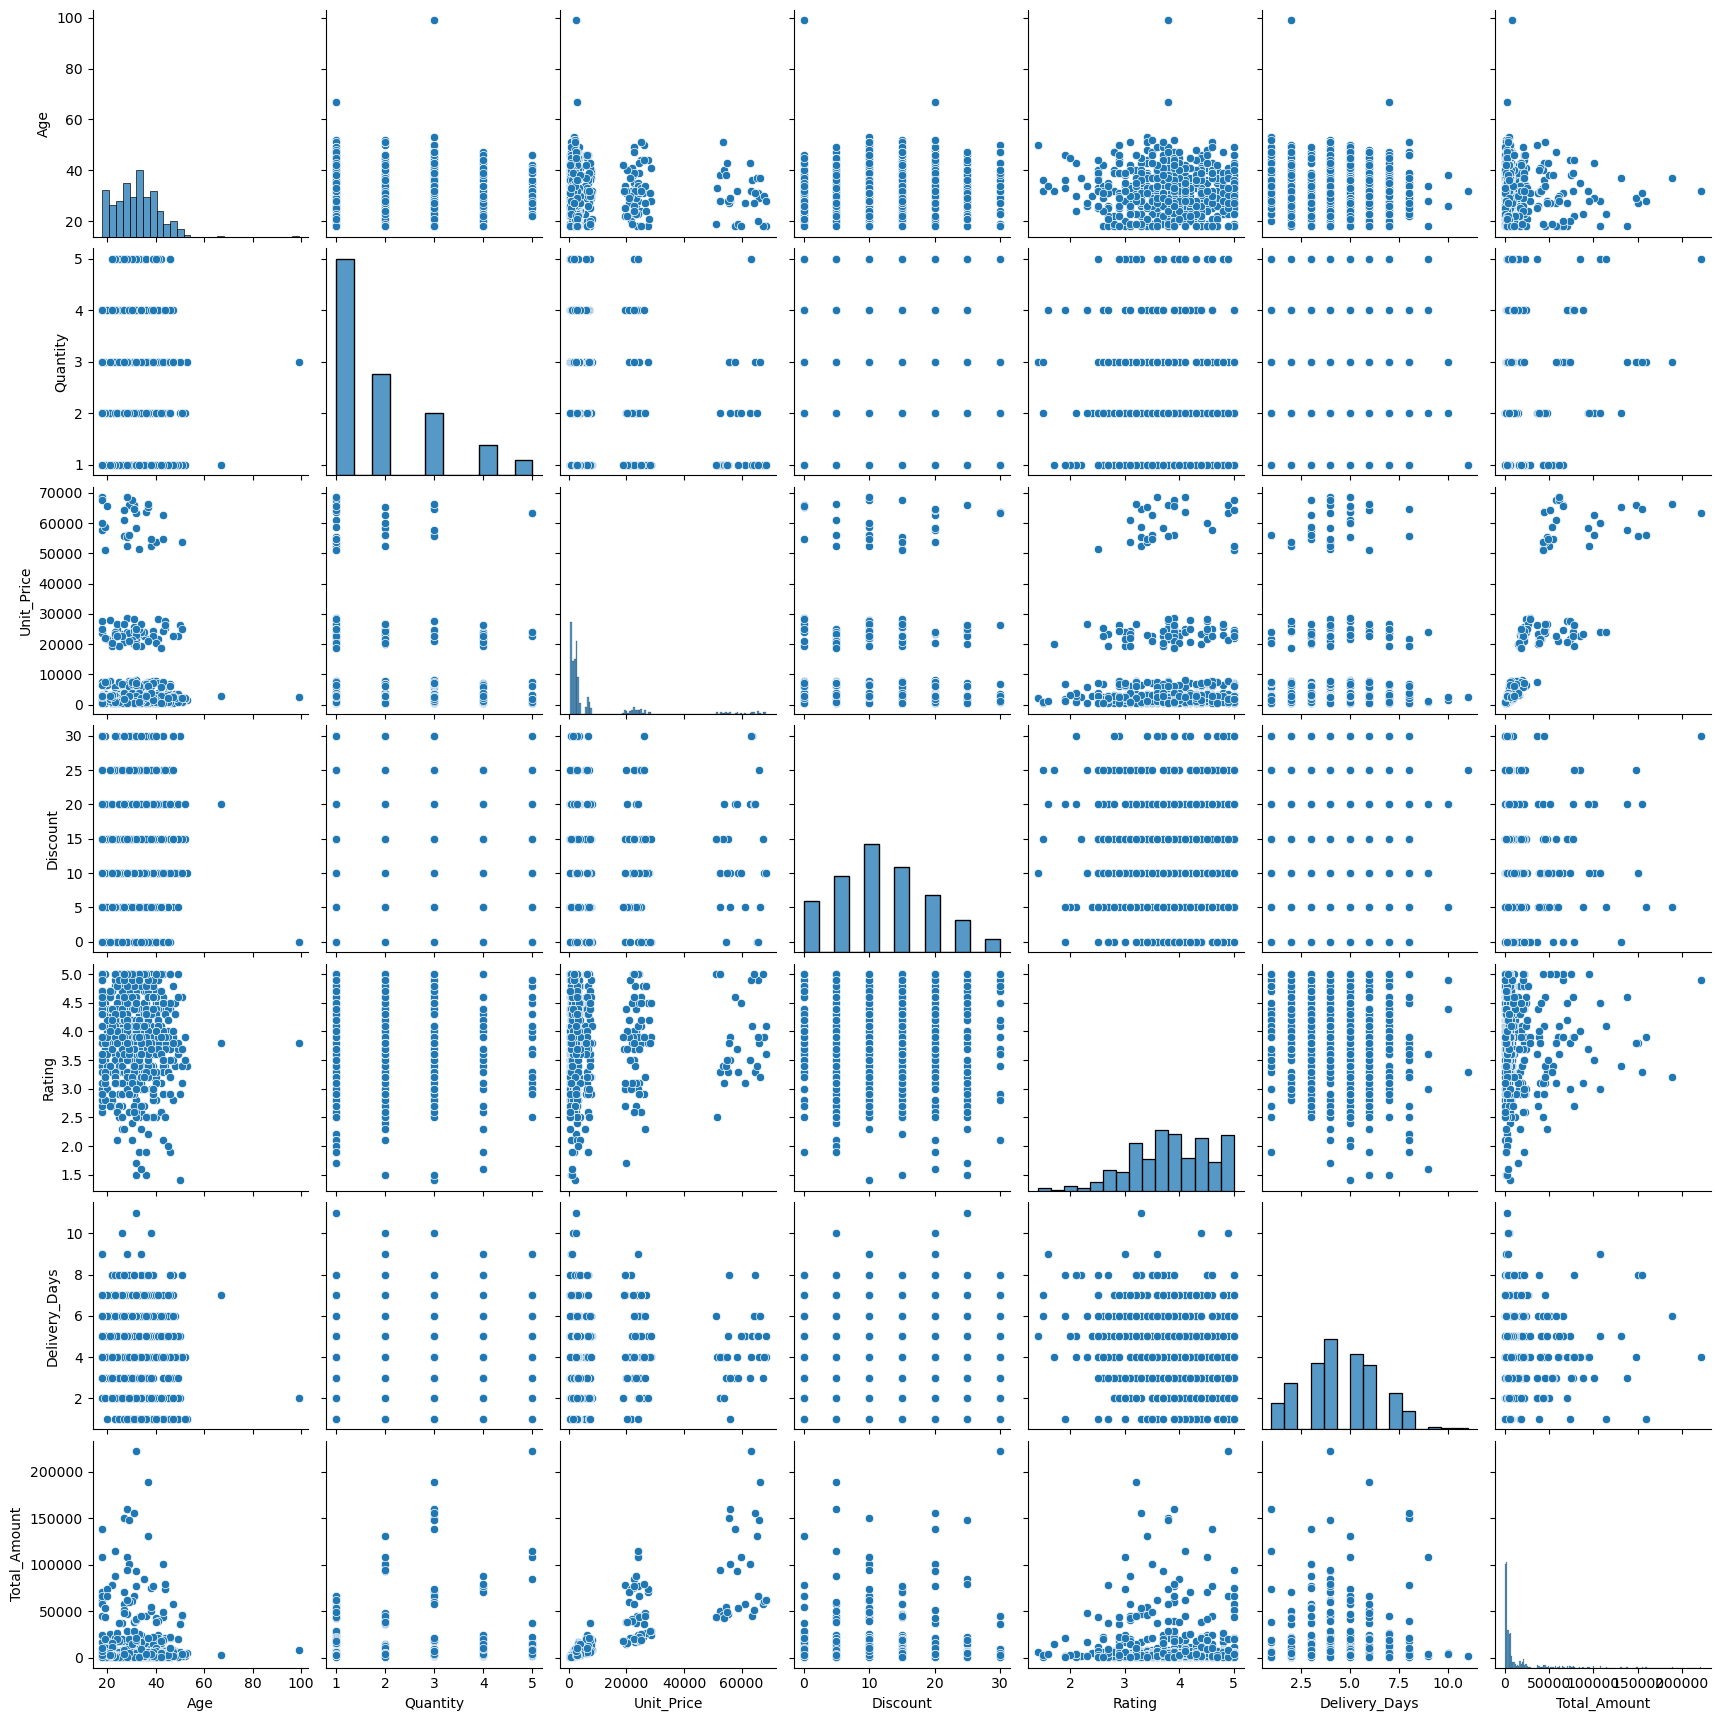

In [92]:
pairplot_cols = [
    "Age",
    "Quantity",
    "Unit_Price",
    "Discount",
    "Rating",
    "Delivery_Days",
    "Total_Amount"
]

sns.pairplot(df[pairplot_cols])

plt.show()

In [ ]:
Observation: The pairplot shows that Unit_Price and Total_Amount have a clear positive relationship,
while most other numerical variables show weak relationships. The distributions also reveal that 
Total_Amount and Unit_Price are highly right-skewed, with some extreme values.

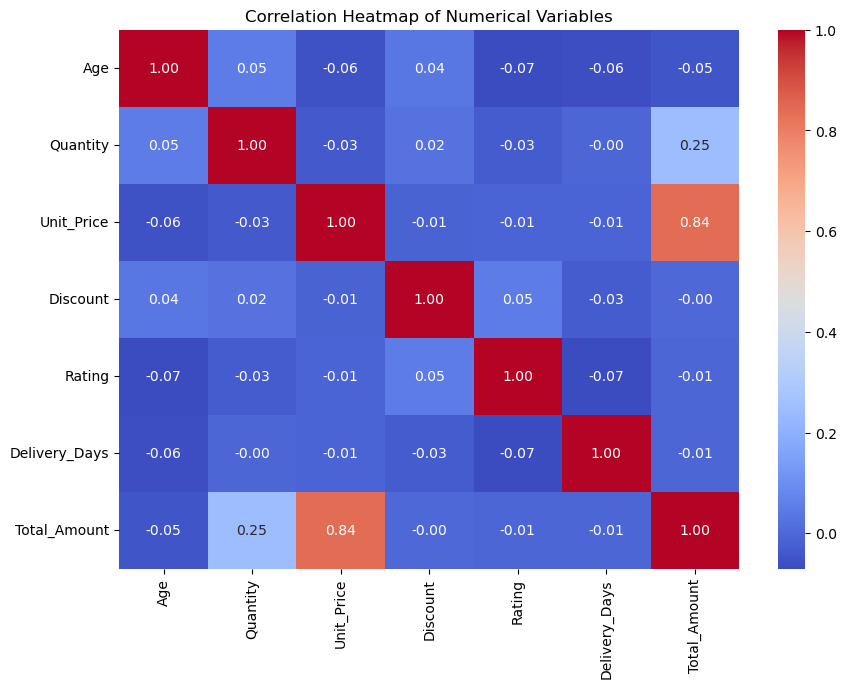

In [93]:
correlation_matrix = df[pairplot_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

In [ ]:
Observation: The correlation heatmap shows that Unit_Price has the strongest positive relationship 
with Total_Amount (0.84), followed by Quantity (0.25). The other variables have very weak correlations
 with Total_Amount, indicating that Unit_Price is the most influential numerical feature for 
 Total_Amount.


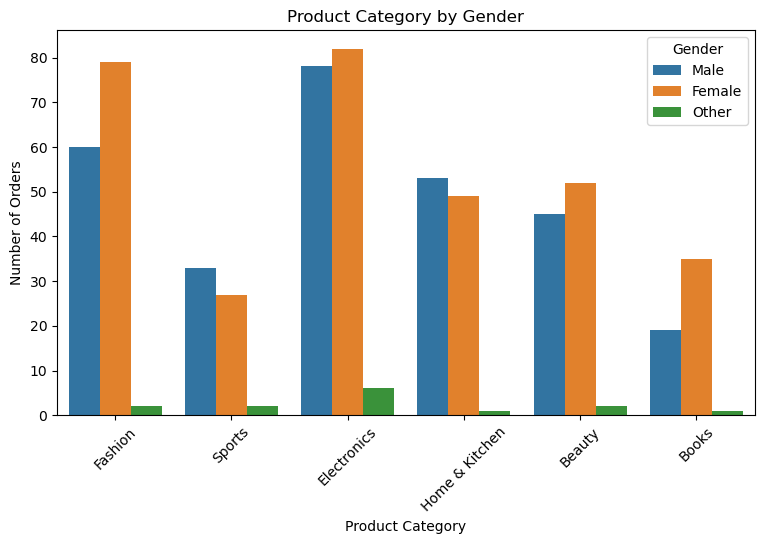

In [94]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Product_Category",
    hue="Gender"
)

plt.title("Product Category by Gender")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

In [ ]:
Observation: The chart shows that Female customers have more orders than Male customers in most 
product categories, especially in Fashion, Electronics, Beauty, and Books. Male customers have 
slightly more orders in Sports and Home & Kitchen, while the Other category has very few orders
across all product categories.

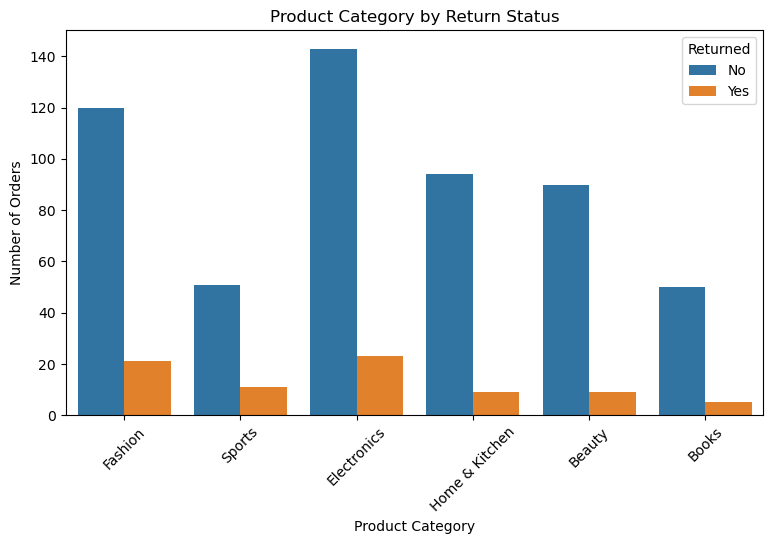

In [95]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Product_Category",
    hue="Returned"
)

plt.title("Product Category by Return Status")
plt.xlabel("Product Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

In [ ]:
Observation: The chart shows that most orders are not returned across all product categories.
Electronics has the highest number of orders and also the highest number of returns, followed by
Fashion. Books has the fewest returned orders, indicating relatively lower return activity.

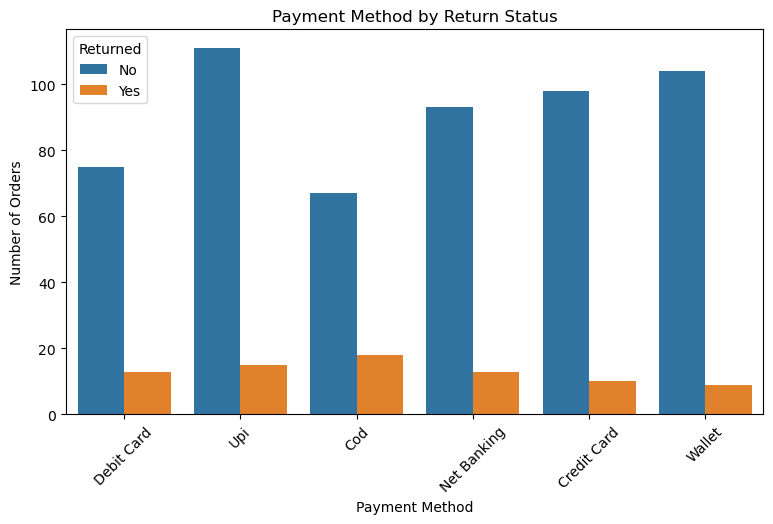

In [96]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Payment_Method",
    hue="Returned"
)

plt.title("Payment Method by Return Status")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()


In [ ]:
Observation: The chart shows that most orders are not returned across all payment methods. UPI has
the highest number of non-returned orders, while COD has the highest number of returned orders. 
Overall, returns are relatively low compared with non-returned orders.

In [97]:
numerical_cols = [
    "Age",
    "Quantity",
    "Unit_Price",
    "Discount",
    "Rating",
    "Delivery_Days",
    "Total_Amount"
]

correlation_matrix = df[numerical_cols].corr()

display(correlation_matrix)

,Age,Quantity,Unit_Price,Discount,Rating,Delivery_Days,Total_Amount
Age,1.000000,0.049252,-0.057312,0.036609,-0.070492,-0.063421,-0.049157
Quantity,0.049252,1.000000,-0.034023,0.022880,-0.031242,-0.004394,0.246444
Unit_Price,-0.057312,-0.034023,1.000000,-0.012475,-0.009227,-0.010635,0.837232
Discount,0.036609,0.022880,-0.012475,1.000000,0.048780,-0.030012,-0.001387
Rating,-0.070492,-0.031242,-0.009227,0.048780,1.000000,-0.069167,-0.006745
Delivery_Days,-0.063421,-0.004394,-0.010635,-0.030012,-0.069167,1.000000,-0.007610
Total_Amount,-0.049157,0.246444,0.837232,-0.001387,-0.006745,-0.007610,1.000000


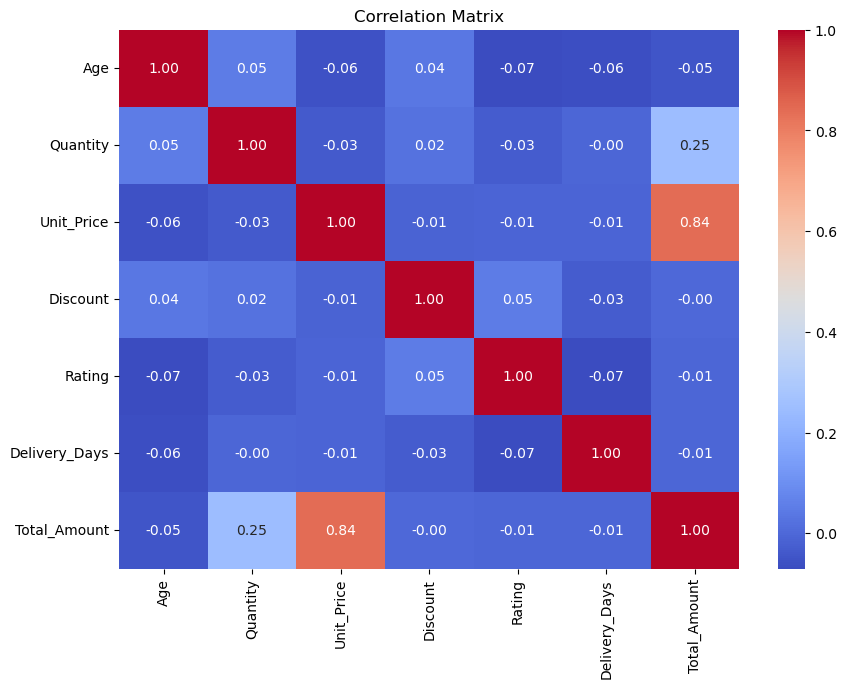

In [98]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [99]:
corr_without_self = correlation_matrix.copy()

np.fill_diagonal(corr_without_self.values, np.nan)

strongest_positive = corr_without_self.stack().idxmax()
positive_value = corr_without_self.stack().max()

strongest_negative = corr_without_self.stack().idxmin()
negative_value = corr_without_self.stack().min()

print("Strongest Positive Correlation:")
print(strongest_positive, "=", positive_value)

print("\nStrongest Negative Correlation:")
print(strongest_negative, "=", negative_value)

Strongest Positive Correlation:
('Unit_Price', 'Total_Amount') = 0.83723152261156

Strongest Negative Correlation:
('Age', 'Rating') = -0.07049197726919942


In [100]:
total_amount_corr = (
    correlation_matrix["Total_Amount"]
    .drop("Total_Amount")
    .sort_values(ascending=False)
)

print("Correlation with Total Amount:")
display(total_amount_corr)

Correlation with Total Amount:


Unit_Price       0.837232
Quantity         0.246444
Discount        -0.001387
Rating          -0.006745
Delivery_Days   -0.007610
Age             -0.049157
Name: Total_Amount, dtype: float64

In [101]:
weak_correlations = total_amount_corr[
    total_amount_corr.abs() < 0.3
]

print("Weak correlations with Total Amount:")
display(weak_correlations)

Weak correlations with Total Amount:


Quantity         0.246444
Discount        -0.001387
Rating          -0.006745
Delivery_Days   -0.007610
Age             -0.049157
Name: Total_Amount, dtype: float64

In [ ]:
Strongest positive correlation: Unit_Price and Total_Amount = 0.8372
This is a strong positive correlation, meaning higher unit prices are generally associated with
higher total order amounts.

Strongest negative correlation: Age and Rating = -0.0705
This is a very weak negative correlation, so Age has almost no linear relationship with Rating.

Variables with weak correlation with Total Amount:
Age = -0.0492
Delivery_Days = -0.0076
Rating = -0.0067
Discount = -0.0014

Quantity has a weak-to-moderate positive correlation with Total Amount at 0.2464.

Variables that may be useful for predicting Total Amount:

Unit_Price (0.8372) — strongest relationship
Quantity (0.2464) — some positive relationship
Final Question

Which features appear to have the strongest relationship with Total Amount?

Answer: Unit_Price has the strongest relationship with Total_Amount (0.8372), followed by
 Quantity (0.2464). Therefore, these two features appear to be the most useful numerical variables
 for understanding Total Amount.

In [102]:
category_orders = df["Product_Category"].value_counts()

print("Orders by Product Category:")
display(category_orders)

print("Most ordered category:",
      category_orders.idxmax())

Orders by Product Category:


Product_Category
Electronics       166
Fashion           141
Home & Kitchen    103
Beauty             99
Sports             62
Books              55
Name: count, dtype: int64

Most ordered category: Electronics


In [103]:
avg_category_amount = (
    df.groupby("Product_Category")["Total_Amount"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Total Amount by Product Category:")
display(avg_category_amount)

print("Category with highest average order value:",
      avg_category_amount.idxmax())

Average Total Amount by Product Category:


Product_Category
Electronics       35644.998976
Home & Kitchen     5239.946796
Sports             3983.685484
Fashion            3130.043121
Beauty             2343.009697
Books              1403.708909
Name: Total_Amount, dtype: float64

Category with highest average order value: Electronics


In [104]:
payment_orders = df["Payment_Method"].value_counts()

print("Orders by Payment Method:")
display(payment_orders)

print("Most popular payment method:",
      payment_orders.idxmax())

Orders by Payment Method:


Payment_Method
Upi            126
Wallet         113
Credit Card    108
Net Banking    106
Debit Card      88
Cod             85
Name: count, dtype: int64

Most popular payment method: Upi


In [105]:
city_sales = (
    df.groupby("City")["Total_Amount"]
    .sum()
    .sort_values(ascending=False)
)

print("Sales by City:")
display(city_sales)

print("City with highest sales:",
      city_sales.idxmax())

Sales by City:


City
Visakhapatnam    958387.05
Ahmedabad        872280.90
Pune             843967.78
Vijayawada       841918.72
Warangal         812335.05
Chennai          531443.83
Kolkata          508427.23
Bengaluru        503867.97
Guntur           475086.72
Mumbai           462047.68
Hyderabad        436973.15
Delhi            207534.80
Name: Total_Amount, dtype: float64

City with highest sales: Visakhapatnam


In [106]:
gender_spending = (
    df.groupby("Gender")["Total_Amount"]
    .mean()
    .sort_values(ascending=False)
)

print("Average spending by Gender:")
display(gender_spending)

print("Gender with highest average spending:",
      gender_spending.idxmax())

Average spending by Gender:


Gender
Other     26812.733571
Male      11749.639062
Female    11404.310370
Name: Total_Amount, dtype: float64

Gender with highest average spending: Other


In [107]:
discount_correlation = df["Discount"].corr(df["Total_Amount"])

print("Correlation between Discount and Total Amount:",
      discount_correlation)

Correlation between Discount and Total Amount: -0.0013869463130974245


In [108]:
product_rating = (
    df.groupby("Product")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Rating by Product:")
display(product_rating)

print("Highest-rated product:",
      product_rating.idxmax())

Average Rating by Product:


Product
Biography            4.213333
Bedsheet             4.190476
Football             4.007143
T-Shirt              3.979310
Exam Guide           3.950000
Jacket               3.944828
Handbag              3.930000
Smartwatch           3.927778
Mixer Grinder        3.927778
Data Science Book    3.912500
Headphones           3.909091
Jeans                3.903571
Hair Dryer           3.894444
Yoga Mat             3.881818
Laptop               3.854839
Perfume              3.852632
Makeup Kit           3.827778
Moisturizer          3.815789
Smartphone           3.809091
Dumbbells            3.791667
Running Shoes        3.775000
Cricket Bat          3.752941
Shoes                3.740000
Tablet               3.736364
Air Fryer            3.713043
Lamp                 3.710000
Cookware Set         3.709524
Face Wash            3.628000
Programming Book     3.608333
Novel                3.237500
Name: Rating, dtype: float64

Highest-rated product: Biography


In [109]:
return_percentage = (
    df["Returned"].value_counts(normalize=True) * 100
)

print("Return Percentage:")
display(return_percentage)

print("Percentage of returned orders:",
      return_percentage.get("Yes", 0))

Return Percentage:


Returned
No     87.539936
Yes    12.460064
Name: proportion, dtype: float64

Percentage of returned orders: 12.460063897763577


In [110]:
delivery_rating_corr = df["Delivery_Days"].corr(df["Rating"])

print("Correlation between Delivery Days and Rating:",
      delivery_rating_corr)

Correlation between Delivery Days and Rating: -0.06916722796311713


In [111]:
total_amount_correlations = (
    df[
        [
            "Age",
            "Quantity",
            "Unit_Price",
            "Discount",
            "Rating",
            "Delivery_Days",
            "Total_Amount"
        ]
    ]
    .corr()["Total_Amount"]
    .drop("Total_Amount")
    .sort_values(ascending=False)
)

print("Correlation with Total Amount:")
display(total_amount_correlations)

Correlation with Total Amount:


Unit_Price       0.837232
Quantity         0.246444
Discount        -0.001387
Rating          -0.006745
Delivery_Days   -0.007610
Age             -0.049157
Name: Total_Amount, dtype: float64

In [ ]:

E-Commerce Data Analysis — Final Report
1. Dataset Description

The dataset contains e-commerce order information including customer, product, payment, rating,
delivery, return, and sales details. After initial preparation, it contained 627 records and 16 
columns. The analysis was performed using Pandas, Matplotlib, and Seaborn.

2. Data Quality Problems Identified

The dataset contained:

Missing values in 7 columns.
Inconsistent categorical values such as Male/male, UPI/upi, and Yes/yes.
1 duplicate record.
Possible outliers in several numerical columns, especially Unit_Price and Total_Amount.
93 records with differences between calculated and existing Total Amount.
3. Data Cleaning Techniques Used

Missing numerical values were filled using the median, and categorical values using the mode.
Categorical values were standardized for consistency.

The duplicate record was removed, reducing the dataset from 627 to 626 records. Outliers were
identified using the IQR method and investigated rather than automatically removed.

4. Exploratory Data Analysis

Histograms, KDE plots, boxplots, countplots, scatterplots, pairplots, and a correlation heatmap were
used.

The analysis showed that Unit_Price has the strongest positive correlation with Total_Amount 
(0.8372), followed by Quantity (0.2464).

5. Important Observations
Electronics has the highest number of orders with 166 orders.
Female is the most common gender.
UPI is the most commonly used payment method.
Most orders were not returned.
Total Amount and Unit Price are right-skewed, with some very high-value orders.
6. Business Insights

Unit_Price and Quantity are the main numerical factors associated with Total Amount. Electronics
contributes significantly to orders and high-value transactions. 
The payment-method analysis shows that UPI is the most frequently used payment method, indicating 
strong customer usage of digital payments.

The relatively small number of returned orders compared with non-returned orders suggests that most 
purchases are successfully retained without returns.

7. Final Conclusion

The dataset was successfully cleaned, validated, and analyzed using Pandas, Matplotlib, and Seaborn.
Missing values and inconsistencies were handled, duplicates were removed, and outliers were
investigated. Unit_Price showed the strongest relationship with Total_Amount, making it an important
variable for understanding sales. The cleaned dataset is suitable for further EDA and business 
analysis.